# LOAD LIBRARIES

In [1]:

import pandas as pd # pandas allows to do a lot of basic data manipulation such as loading csv data files
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt # matplotlib is a basic ploting library of Python
from scipy.stats import lognorm 
from pathlib import Path
from diive.core.io.files import save_parquet, load_parquet

Custom plotting function

In [2]:
def plot_data_grid(indat, ncols=3):
    vars = indat.columns
    nrows = (len(vars) + ncols - 1) // ncols  # Calculate the number of rows needed
    relative_markersize = max(1, 10 / len(vars))  # Scale marker size inversely to the number of plots
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), constrained_layout=True)
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    
    for ax, var in zip(axes, vars):
        ax.plot(indat[var], marker='o', markersize=relative_markersize, label=var)
        ax.set_xlabel('Time')
        ax.set_ylabel(var)
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
    
    # Remove any unused subplots
    for ax in axes[len(vars):]:
        fig.delaxes(ax)
    
    plt.show()

# READ DATA

## FLUXES

Loaded .parquet file ../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (0.600 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Loaded .parquet file ../81_NEE/81.7.1_NEE_GF-XGBoost_GPP_RECO.parquet (0.068 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


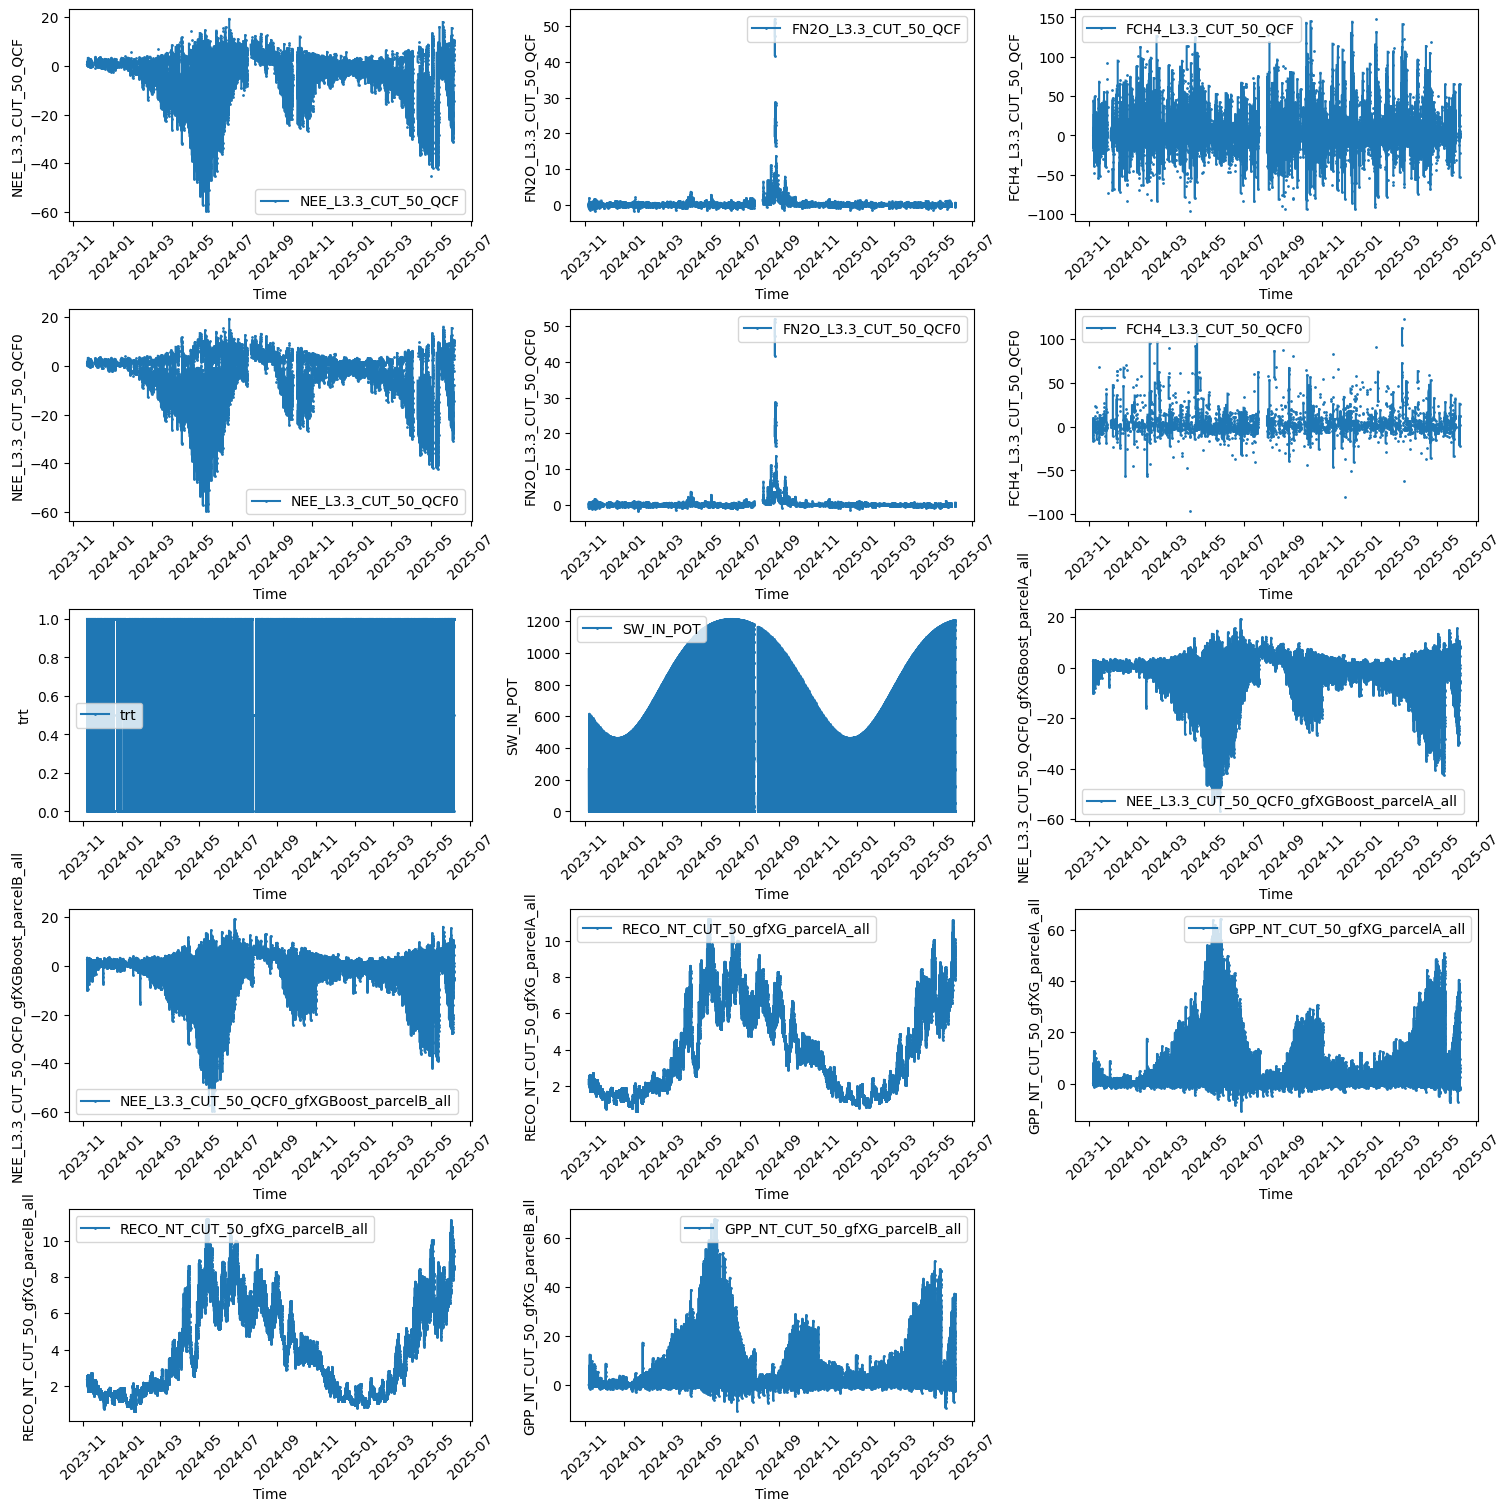

,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,trt,SW_IN_POT,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,RECO_NT_CUT_50_gfXG_parcelA_all,GPP_NT_CUT_50_gfXG_parcelA_all,RECO_NT_CUT_50_gfXG_parcelB_all,GPP_NT_CUT_50_gfXG_parcelB_all
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,
2023-11-06 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.328763,0.013861,2.328763,0.013861
2023-11-06 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.325954,0.016817,2.325954,0.016817
2023-11-07 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.297859,0.022451,2.297859,0.022451
2023-11-07 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.261322,0.016674,2.261322,0.016674
2023-11-07 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.165719,-0.079909,2.165719,-0.079909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.557946,8.557946,NaN,NaN,NaN,NaN
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.263685,8.263685,NaN,NaN,NaN,NaN
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.384712,8.384712,NaN,NaN,NaN,NaN


In [3]:
fluxes = load_parquet(filepath=r"../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet")
NEE_results = load_parquet(filepath=r"../81_NEE/81.7.1_NEE_GF-XGBoost_GPP_RECO.parquet")
NEE_results = NEE_results.filter(regex=r'(QCF0|GPP|RECO).*all$') # keep only one version
fluxes = pd.concat([fluxes, NEE_results] , axis=1)

qcf_cols = [c for c in fluxes.columns if c.endswith('CUT_50_QCF')]
qcf0_cols = [c for c in fluxes.columns if c.endswith('CUT_50_QCF0')]

cols = qcf_cols + qcf0_cols + ['parcel', 'parcel_certainty', 'trt'] + ['SW_IN_POT'] + NEE_results.columns.tolist()

fluxes = fluxes[cols].copy()

# plots
indat = fluxes.drop(columns=['parcel', 'parcel_certainty'])
plot_data_grid(indat, ncols=3)

# show data
fluxes

## METEO

Bulk density data used for WFPS calculation was measured on May 2025.
See file CH-TAN_20250520_soil_bulk_density.xlsx

Loaded .parquet file ../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.189 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


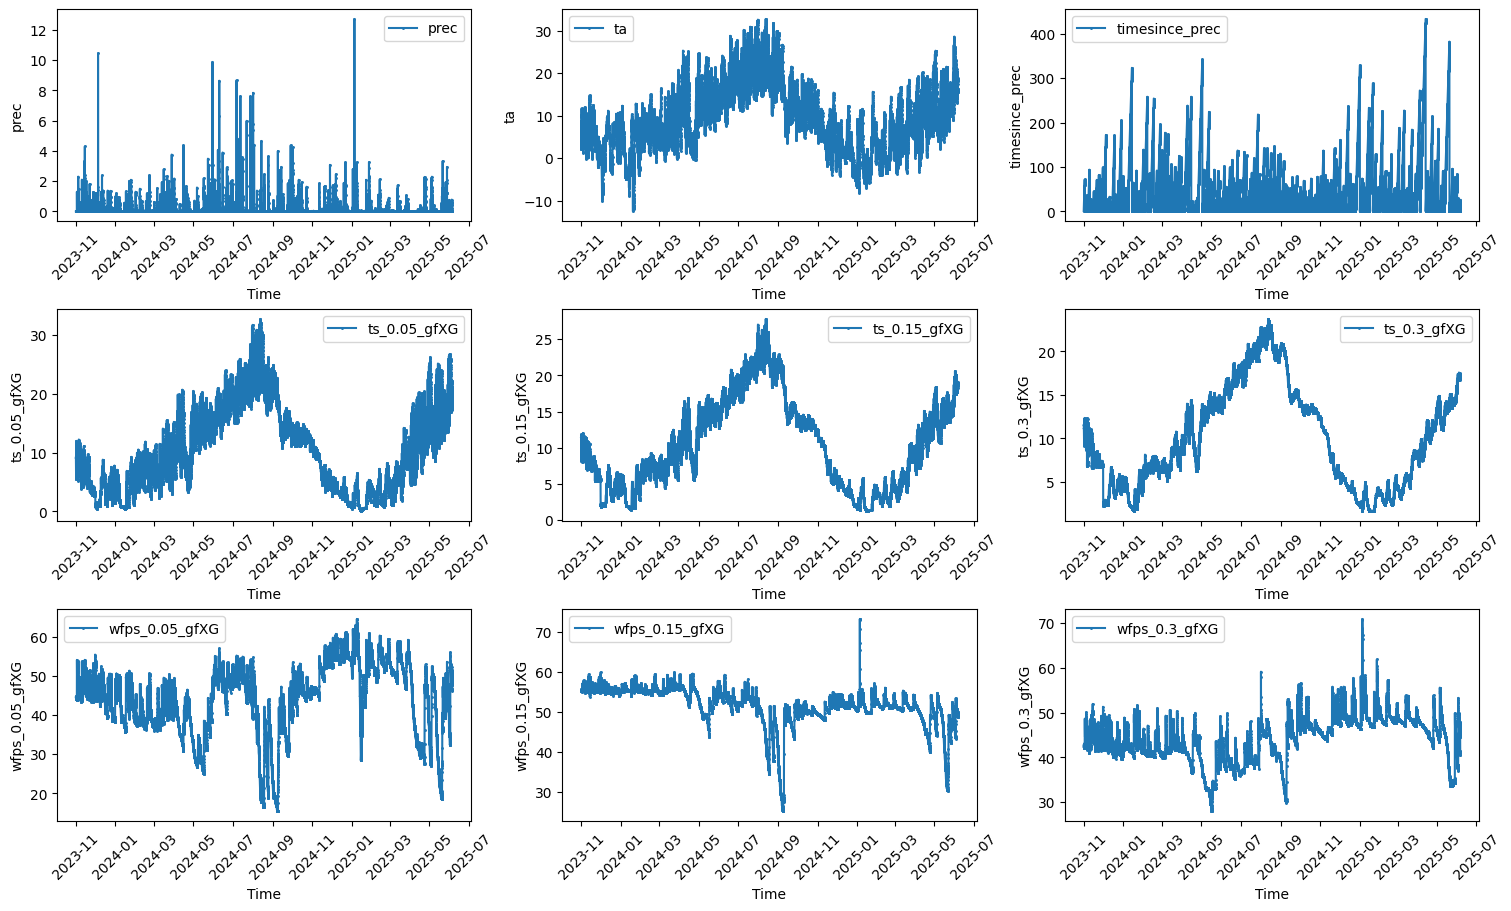

,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG
TIMESTAMP_MIDDLE,,,,,,,,,
2023-10-31 23:45:00,0.0,8.000000,1,9.098388,11.378627,11.530369,44.506302,55.538911,42.353099
2023-11-01 00:15:00,0.0,8.633333,2,9.154857,11.409856,11.225279,44.507284,55.221947,42.530532
2023-11-01 00:45:00,0.0,8.266667,3,9.216592,11.371663,11.158751,44.466206,55.137338,42.519273
2023-11-01 01:15:00,0.0,6.966667,4,9.287736,11.434952,11.346931,44.482367,55.254504,42.686566
2023-11-01 01:45:00,0.0,5.666667,5,9.090844,11.641592,11.395833,44.505722,55.255965,42.709687
...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,0.0,15.833333,22,18.565866,18.817616,17.117313,47.661621,48.667096,41.341274
2025-06-05 22:15:00,0.0,15.733333,23,18.389761,18.866354,16.990484,46.519816,48.765574,40.453896
2025-06-05 22:45:00,0.0,16.200000,24,18.252666,18.519451,17.198946,46.053434,48.760014,40.437537


In [4]:
meteo = load_parquet(filepath=r"../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")

cols =['prec',
       'ta',
       'timesince_prec', 
       'ts_0.05_gfXG',
       'ts_0.15_gfXG', 
       'ts_0.3_gfXG',
       'swc_0.05_gfXG',
       'swc_0.15_gfXG',
       'swc_0.3_gfXG'
       ]

meteo = meteo[cols]

# Calculate WFPS from SWC using formula with bulk density and particle density
bulk_density = {
    '0.05': 1.1, 
    '0.15': 1.1, 
    '0.3': 1.2, 
}

# Standard particle density since it was not measured
particle_density = 2.65

# Iterate over SWC columns and compute WFPS
swc_cols = [col for col in meteo if col.startswith('swc_')]
for col in swc_cols:
    new_name = col.replace('swc', 'wfps')
    for depth, bd in bulk_density.items():
        if depth in col:
            # calculate wfps for current depth
            wfps = meteo[col] / (1 - (bd / particle_density)) # no need to multiply by 100 because swc is in percent
            meteo[new_name] = wfps
            break

# Now we can remove all the swc columns from which we calculated wfps
meteo.drop(columns=swc_cols, inplace=True)

# plots
plot_data_grid(meteo, ncols=3)

# show data
meteo

## MANAGEMENT

Loaded .parquet file ../../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet (0.080 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


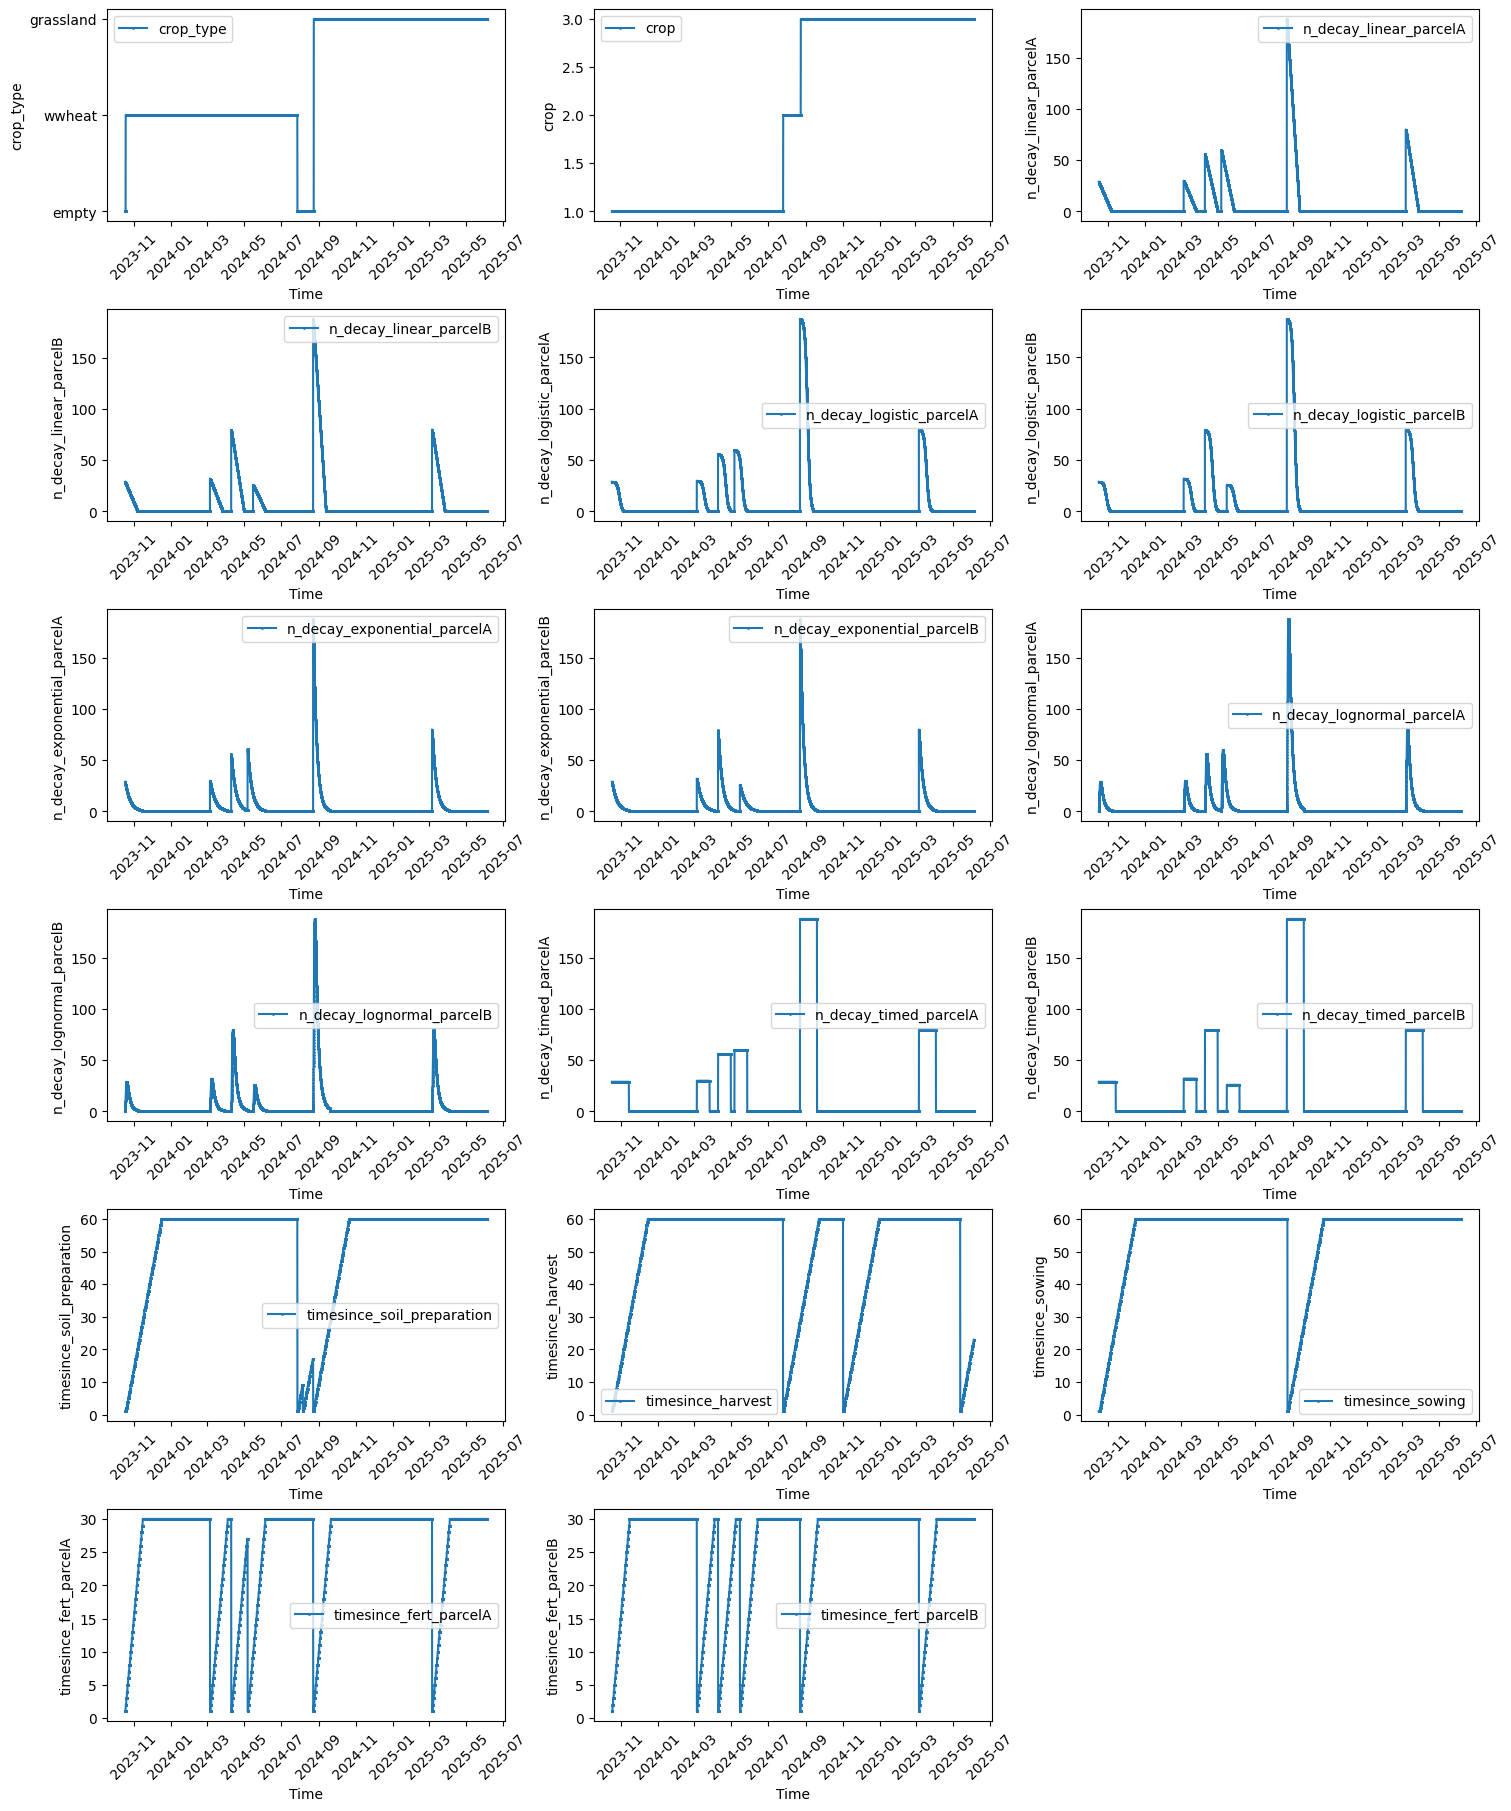

,crop_type,crop,n_decay_linear_parcelA,n_decay_linear_parcelB,n_decay_logistic_parcelA,n_decay_logistic_parcelB,n_decay_exponential_parcelA,n_decay_exponential_parcelB,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,
2023-10-17 12:15:00,empty,NaN,29.000000,29.000000,28.908905,28.908905,29.000000,29.000000,2.808299e-07,2.808299e-07,29.0,29.0,1,1,1,1,1
2023-10-17 12:45:00,empty,NaN,28.971230,28.971230,28.907992,28.907992,28.927434,28.927434,3.727140e-05,3.727140e-05,29.0,29.0,1,1,1,1,1
2023-10-17 13:15:00,empty,NaN,28.942460,28.942460,28.907070,28.907070,28.855049,28.855049,4.592764e-04,4.592764e-04,29.0,29.0,1,1,1,1,1
2023-10-17 13:45:00,empty,NaN,28.913690,28.913690,28.906140,28.906140,28.782845,28.782845,2.334962e-03,2.334962e-03,29.0,29.0,1,1,1,1,1
2023-10-17 14:15:00,empty,NaN,28.884921,28.884921,28.905199,28.905199,28.710822,28.710822,7.540160e-03,7.540160e-03,29.0,29.0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,grassland,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,60,23,60,30,30
2025-06-04 22:15:00,grassland,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,60,23,60,30,30
2025-06-04 22:45:00,grassland,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,60,23,60,30,30


In [5]:
management = load_parquet(filepath=r"../../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet")

# select subset of columns
prefix = ('n_decay', 'timesince', 'timed', 'crop')
cols = [c for c in management.columns if c.startswith(prefix)]
management = management[cols]

# plots
plot_data_grid(management, ncols=3)

# show data
management

## CANOPY

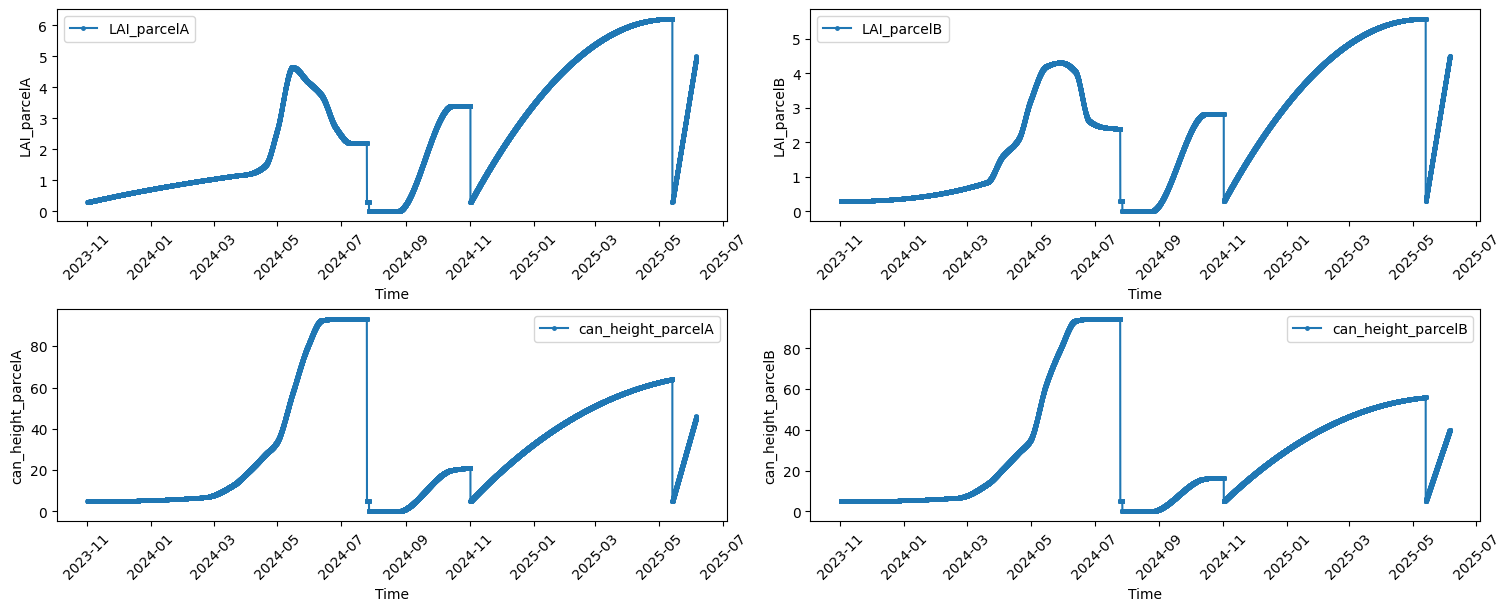

,LAI_parcelA,LAI_parcelB,can_height_parcelA,can_height_parcelB
TIMESTAMP_MIDDLE,,,,
2023-11-01 12:15:00,0.300000,0.300000,5.000000,5.000000
2023-11-01 12:45:00,0.300160,0.300000,5.000000,5.000000
2023-11-01 13:15:00,0.300321,0.300000,5.000000,5.000000
2023-11-01 13:45:00,0.300481,0.300000,5.000000,5.000000
2023-11-01 14:15:00,0.300641,0.300000,5.000001,5.000001
...,...,...,...,...
2025-06-05 10:15:00,4.982956,4.484769,45.851315,39.873073
2025-06-05 10:45:00,4.987217,4.488577,45.888486,39.904805
2025-06-05 11:15:00,4.991478,4.492384,45.925657,39.936537


In [6]:
vars_ = ["LAI", "can_height"]
canopy = None
for var in vars_:
    df = pd.read_csv(f"../../../data/CANOPY/02-{var}_model.csv")
    canopy = df if canopy is None else canopy.merge(df, on='TIMESTAMP_MIDDLE', how="outer")

canopy = canopy.sort_values('TIMESTAMP_MIDDLE')
canopy['TIMESTAMP_MIDDLE'] = pd.to_datetime(canopy['TIMESTAMP_MIDDLE'])
canopy.set_index('TIMESTAMP_MIDDLE', inplace=True)

canopy = canopy[[c for c in canopy if 'parcel' in c]]

# plots
plot_data_grid(canopy, ncols=2)

# show data
canopy

# MERGE DATA

## MERGE

In [7]:
df = pd.concat([fluxes, meteo, management, canopy], axis=1)

## SANITIZE TIMESTAMP

In [8]:
# Remove duplicates, keep first
locs_duplicates = df.index.duplicated(keep='first')
print(f"Found duplicates in index: {locs_duplicates.sum()}")
df = df[~locs_duplicates]

# Remove NaTs
locs_nats = df.index.isnull()
print(f"Found NaTs in index: {locs_nats.sum()}")
df = df[~locs_nats]

# Sort timestamp index
df = df.sort_index(ascending=True)

df

Found duplicates in index: 0
Found NaTs in index: 0


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,trt,SW_IN_POT,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,RECO_NT_CUT_50_gfXG_parcelA_all,GPP_NT_CUT_50_gfXG_parcelA_all,RECO_NT_CUT_50_gfXG_parcelB_all,...,n_decay_exponential_parcelA,n_decay_exponential_parcelB,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,LAI_parcelA,LAI_parcelB,can_height_parcelA,can_height_parcelB
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,29.000000,29.000000,2.808299e-07,2.808299e-07,29.0,29.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2023-10-17 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.927434,28.927434,3.727140e-05,3.727140e-05,29.0,29.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2023-10-17 13:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.855049,28.855049,4.592764e-04,4.592764e-04,29.0,29.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2023-10-17 13:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.782845,28.782845,2.334962e-03,2.334962e-03,29.0,29.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2023-10-17 14:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.710822,28.710822,7.540160e-03,7.540160e-03,29.0,29.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.557946,8.557946,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.263685,8.263685,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.384712,8.384712,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.columns

Index(['NEE_L3.3_CUT_50_QCF', 'FN2O_L3.3_CUT_50_QCF', 'FCH4_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_50_QCF0', 'FN2O_L3.3_CUT_50_QCF0', 'FCH4_L3.3_CUT_50_QCF0', 'parcel', 'parcel_certainty', 'trt', 'SW_IN_POT', 'NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all', 'NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all', 'RECO_NT_CUT_50_gfXG_parcelA_all', 'GPP_NT_CUT_50_gfXG_parcelA_all', 'RECO_NT_CUT_50_gfXG_parcelB_all', 'GPP_NT_CUT_50_gfXG_parcelB_all', 'prec', 'ta', 'timesince_prec', 'ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG', 'crop_type', 'crop', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_soil_preparation', 'timesince_harvest', 'timesince_sowing', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'LAI_parcelA',

# LAGGED VARIANTS

Variables for which lagged variants will be calculated:

In [10]:
# Define columns of interest
_list_lag_vars = [
    'NEE_L3.3_CUT_50_QCF_gfXGBoost',
    'GPP_NT_CUT_50_gfXG','RECO_NT_CUT_50_gfXG',
    'prec',
    'ta',
    'ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 
    'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG'
]

_list_lag_vars = [c for c in df.columns if any([c.startswith(v) for v in _list_lag_vars])]

_list_lag_vars

['RECO_NT_CUT_50_gfXG_parcelA_all',
 'GPP_NT_CUT_50_gfXG_parcelA_all',
 'RECO_NT_CUT_50_gfXG_parcelB_all',
 'GPP_NT_CUT_50_gfXG_parcelB_all',
 'prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG']

Calculate the lagged variants

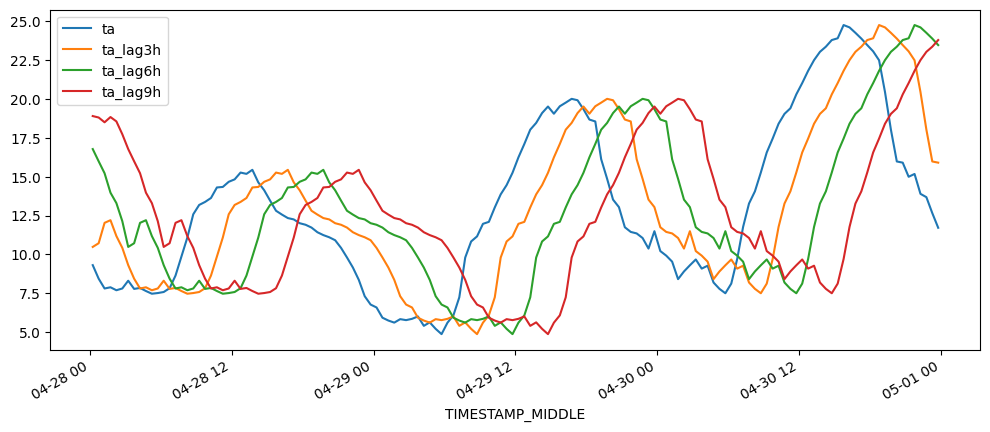

In [11]:
# Define time intervals
intervals = [3, 6, 9] # in hours

# Time resolution of the dataframe
time_res = 0.5

# Create lagged variants
for v in _list_lag_vars:
    for lag in intervals:
        lag_adjusted = int(lag/time_res)
        if lag_adjusted > 0:
            var_lag = f'{v}_lag{lag}h'
            df[var_lag] = df[v].shift(lag_adjusted)

# Plot the lag vars for TA
indat = df[[c for c in df.columns if c.startswith('ta')]]
indat = indat.loc['2024-04-28':'2024-04-30']
indat.plot(x_compat=True, figsize=(12, 5));

# ROLLING VARIANTS

Variables for which rolling variants will be calculated:

In [12]:
# Define columns of interest
_list_rolling_vars = [c for c in df.columns if c.startswith(tuple(_list_lag_vars))]
_list_rolling_vars

['RECO_NT_CUT_50_gfXG_parcelA_all',
 'GPP_NT_CUT_50_gfXG_parcelA_all',
 'RECO_NT_CUT_50_gfXG_parcelB_all',
 'GPP_NT_CUT_50_gfXG_parcelB_all',
 'prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG',
 'RECO_NT_CUT_50_gfXG_parcelA_all_lag3h',
 'RECO_NT_CUT_50_gfXG_parcelA_all_lag6h',
 'RECO_NT_CUT_50_gfXG_parcelA_all_lag9h',
 'GPP_NT_CUT_50_gfXG_parcelA_all_lag3h',
 'GPP_NT_CUT_50_gfXG_parcelA_all_lag6h',
 'GPP_NT_CUT_50_gfXG_parcelA_all_lag9h',
 'RECO_NT_CUT_50_gfXG_parcelB_all_lag3h',
 'RECO_NT_CUT_50_gfXG_parcelB_all_lag6h',
 'RECO_NT_CUT_50_gfXG_parcelB_all_lag9h',
 'GPP_NT_CUT_50_gfXG_parcelB_all_lag3h',
 'GPP_NT_CUT_50_gfXG_parcelB_all_lag6h',
 'GPP_NT_CUT_50_gfXG_parcelB_all_lag9h',
 'prec_lag3h',
 'prec_lag6h',
 'prec_lag9h',
 'ta_lag3h',
 'ta_lag6h',
 'ta_lag9h',
 'ts_0.05_gfXG_lag3h',
 'ts_0.05_gfXG_lag6h',
 'ts_0.05_gfXG_lag9h',
 'ts_0.15_gfXG_lag3h',
 'ts_0.15_gfXG_lag6h',
 'ts_0.15_gfXG_lag9h',
 'ts_0.3_gfXG_la

Calculate the rolling variants

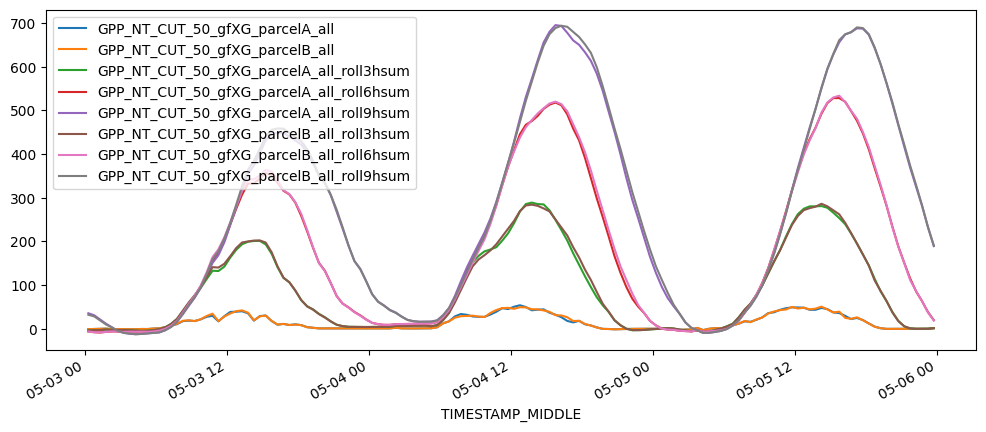

In [13]:
# Define time intervals
intervals = [3, 6, 9] # in hours

# Time resolution of the dataframe
time_res = 0.5

# Define the type of aggregations we will apply
aggtypes_default = ['mean']
aggtypes_sum = ['sum'] # for 'prec', 'GPP', 'Reco', 'NEE'


# Create rolling variants
for v in _list_rolling_vars:
    # Determine aggregation type
    aggtypes = aggtypes_sum if v.startswith(('prec', 'GPP', 'Reco', 'NEE')) else aggtypes_default
    for interval in intervals:
        interval_adjusted = int(interval/time_res)
        if interval_adjusted > 0:
            for agg in aggtypes:
                var_roll = f'{v}_roll{interval}h{agg}'
                df[var_roll] = df[v].rolling(interval_adjusted, min_periods=1).agg(agg)
                df = df.copy()

# Plot the lag vars for GPP
indat = df[[c for c in df.columns if c.startswith('GPP') and 'lag' not in c]]
indat = indat.loc['2024-05-03':'2024-05-05']
indat.plot(x_compat=True, figsize=(12,5));

# RATE OF CHANGE

Used for WFPS and TS

In [14]:
# define columns of interest
_list_diff_vars = [col for col in df.columns if ('ts' in col or 'wfps' in col) and ('roll' not in col and 'lag' not in col)]

print(f'We calculate the rate of change for these variables: {_list_diff_vars}')

We calculate the rate of change for these variables: ['ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG']


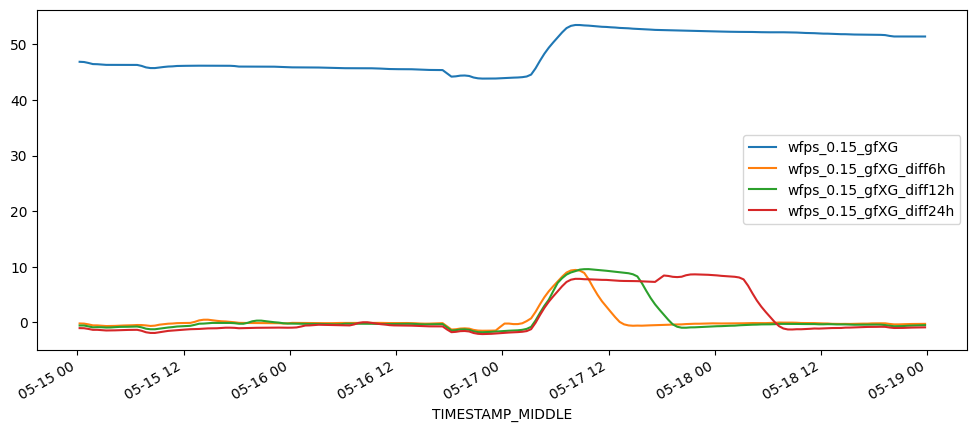

In [15]:
# Define interval of records for the difference calculation
intervals = [6, 12, 24] # in hours


# Time resolution of the dataframe
time_res = 0.5

# Create the variants
for v in _list_diff_vars:
    for interval in intervals:
        interval_adjusted = int(interval/time_res)
        if interval_adjusted > 0:
            var_diff = f'{v}_diff{interval}h'
            df[var_diff] = df[v].diff(periods=interval_adjusted)


# Plot the lag vars for wfps_0.15

indat = df[[c for c in df.columns if c.startswith('wfps_0.15') and 'lag' not in c and 'roll' not in c]]
indat = indat.loc['2024-05-15':'2024-05-18']
indat.plot(x_compat=True, figsize=(12, 5));

# MERGE PARCEL-SPECIFIC COLS

C:\Users\turcof\AppData\Local\Temp\ipykernel_5172\304218986.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7, 3))


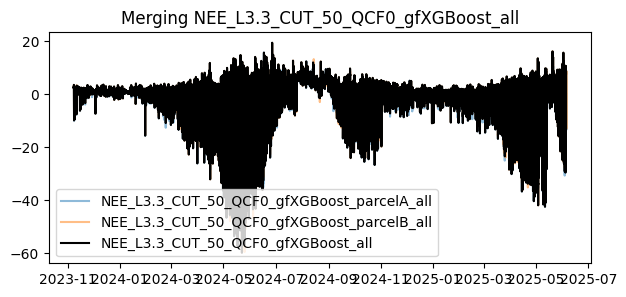

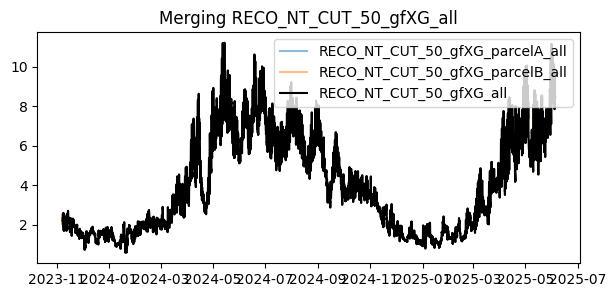

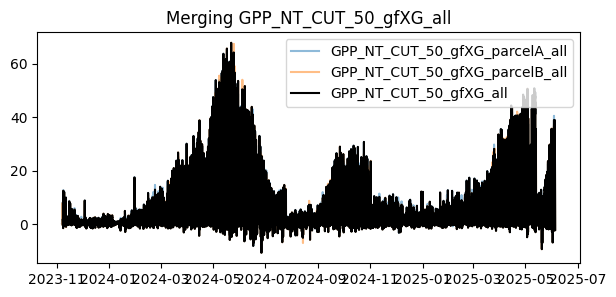

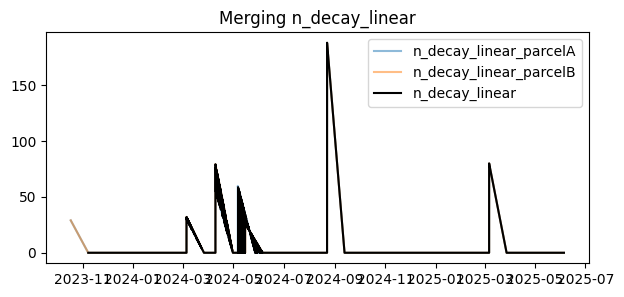

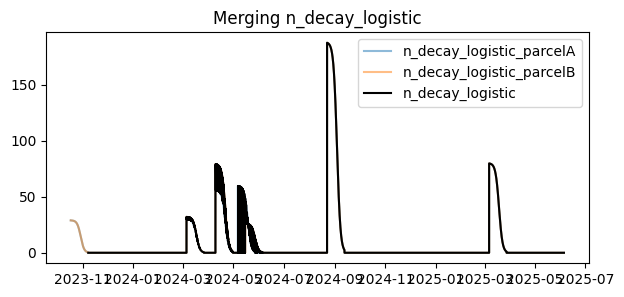

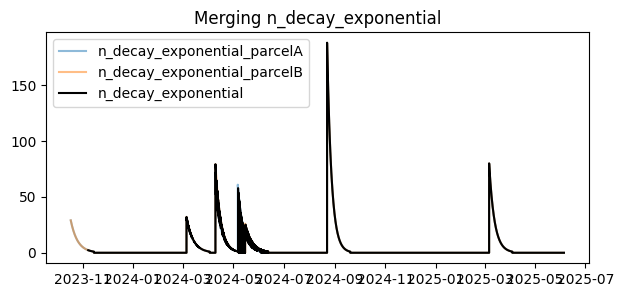

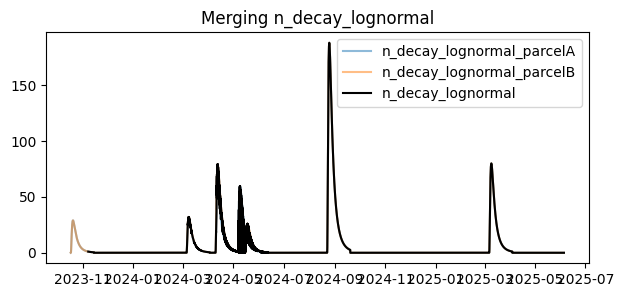

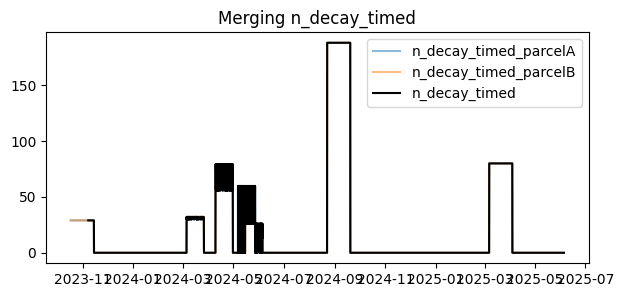

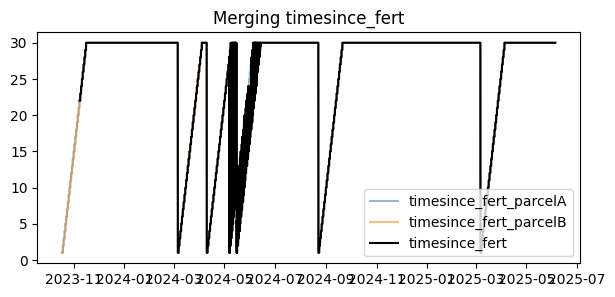

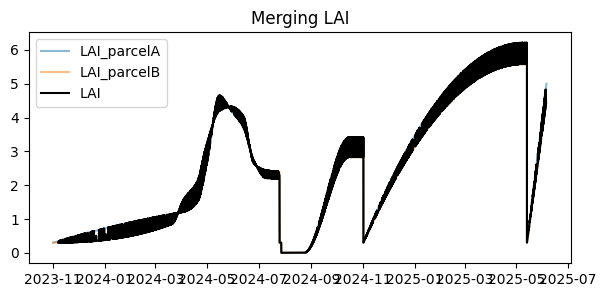

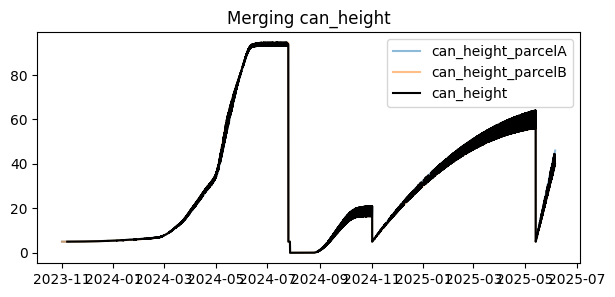

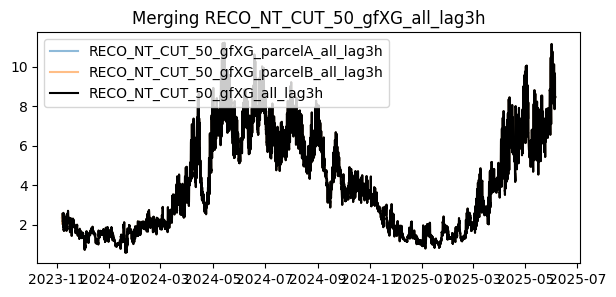

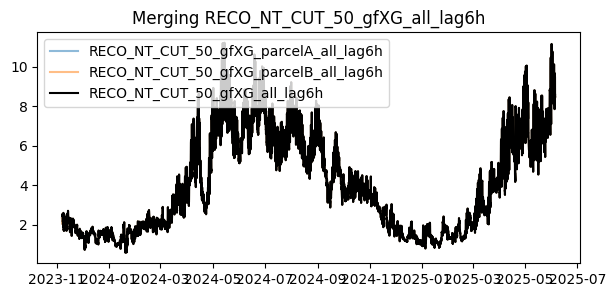

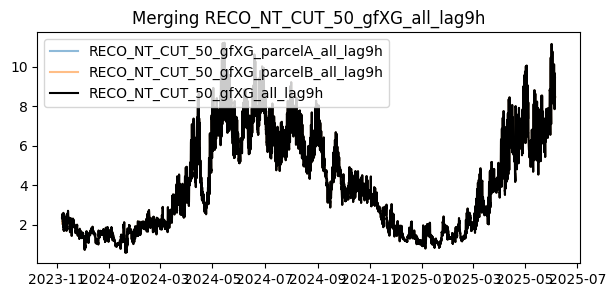

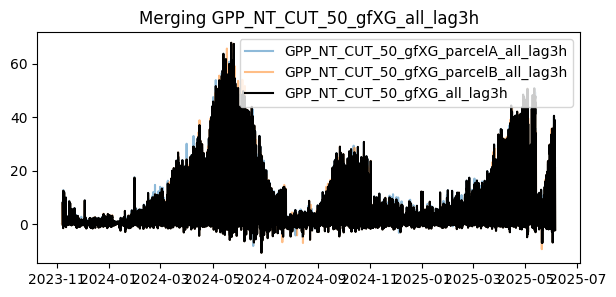

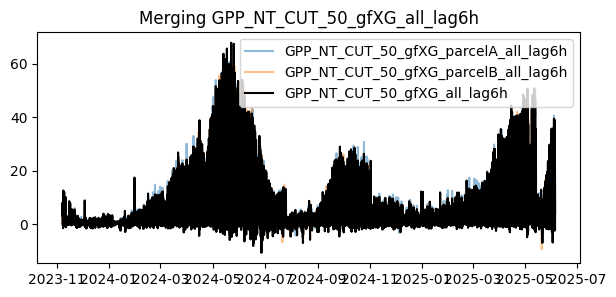

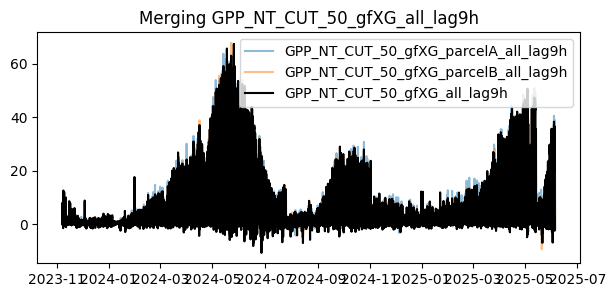

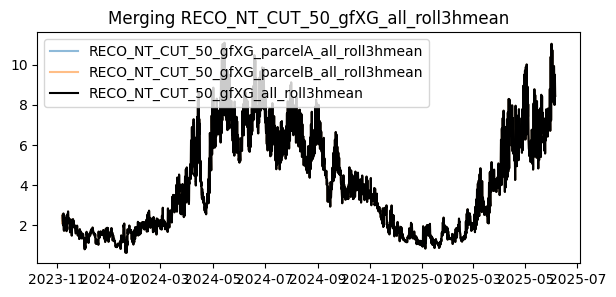

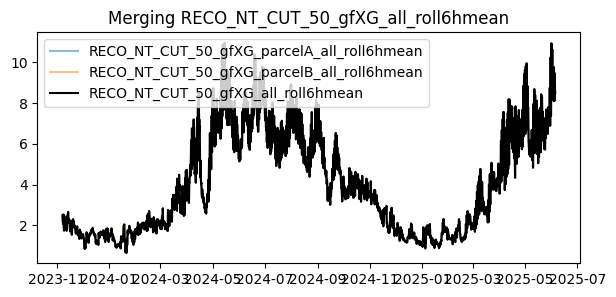

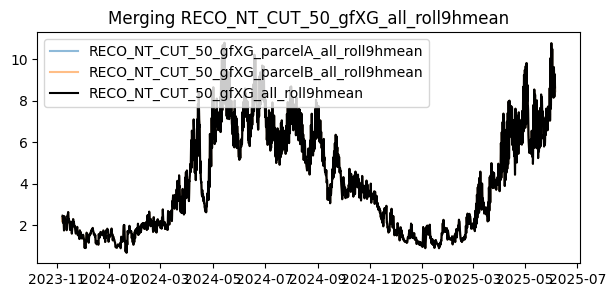

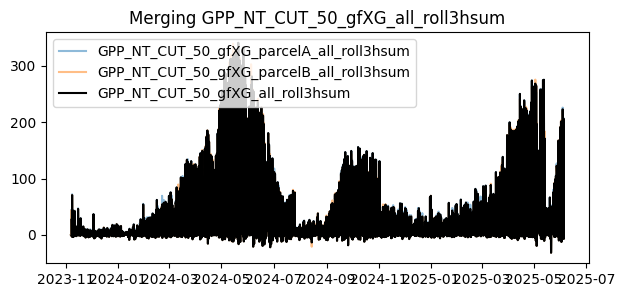

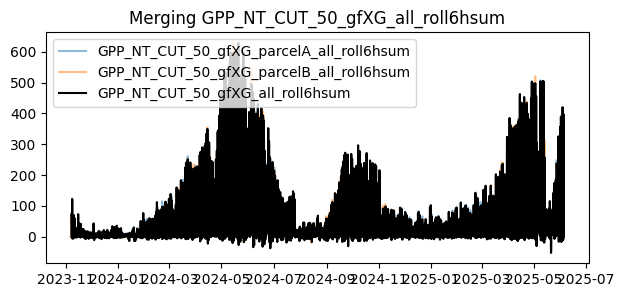

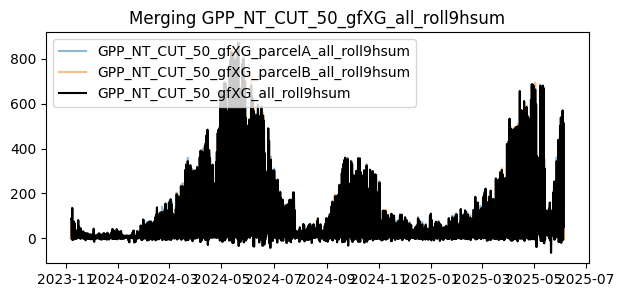

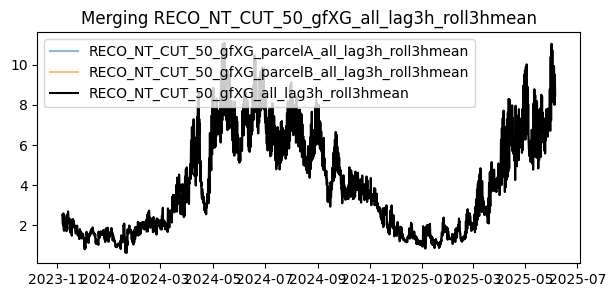

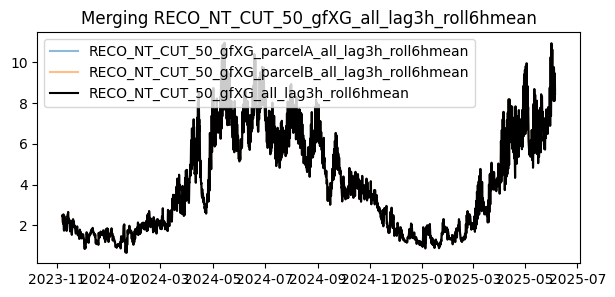

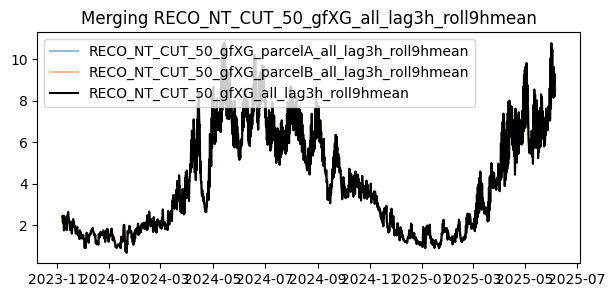

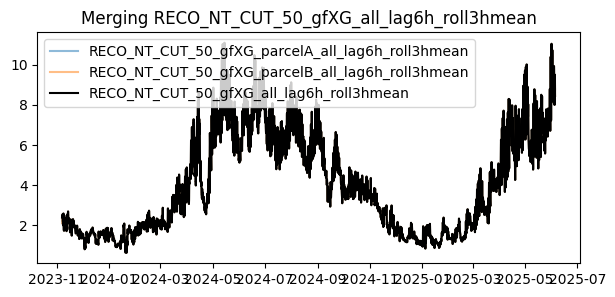

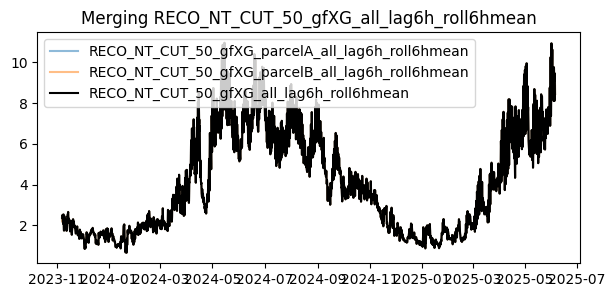

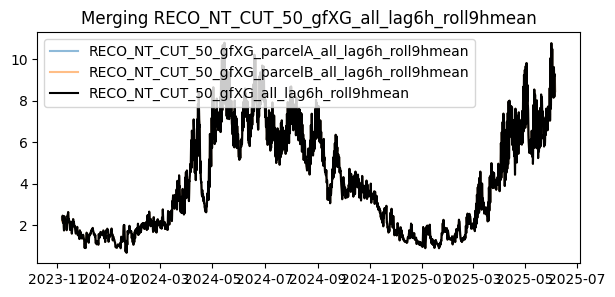

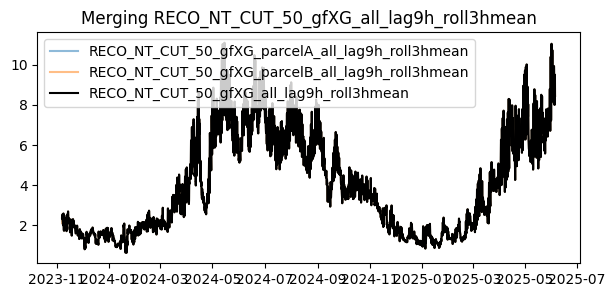

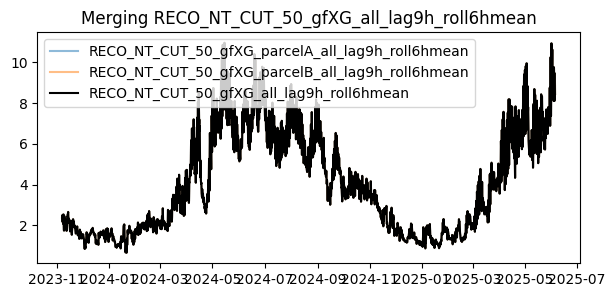

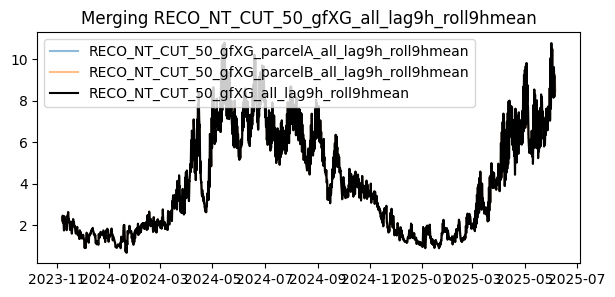

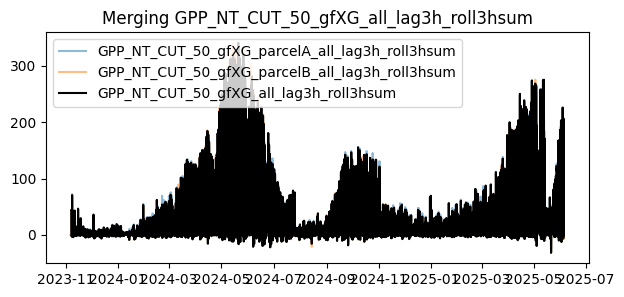

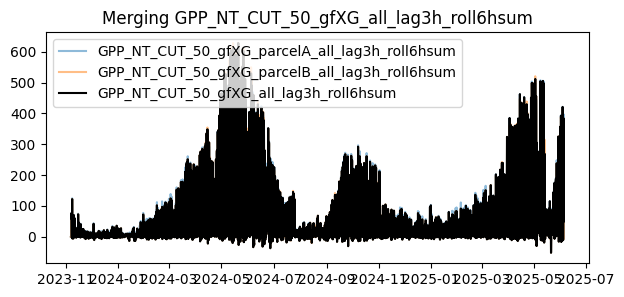

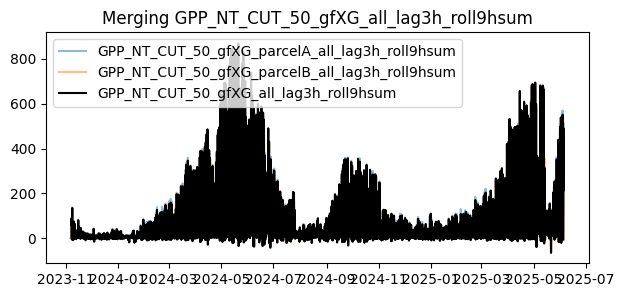

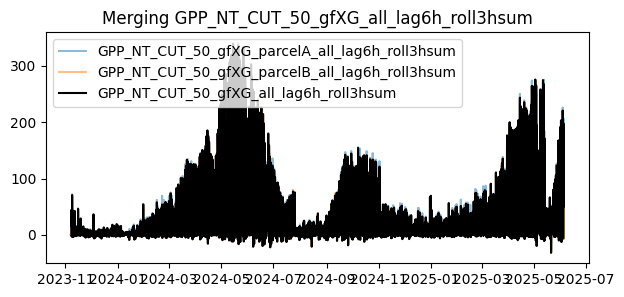

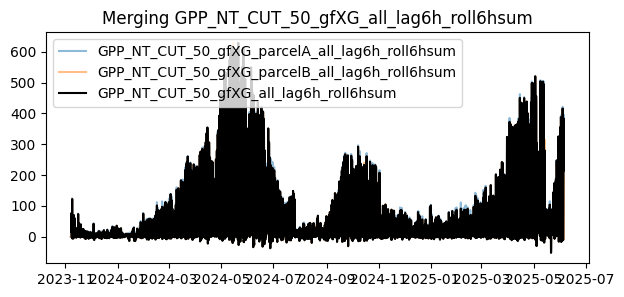

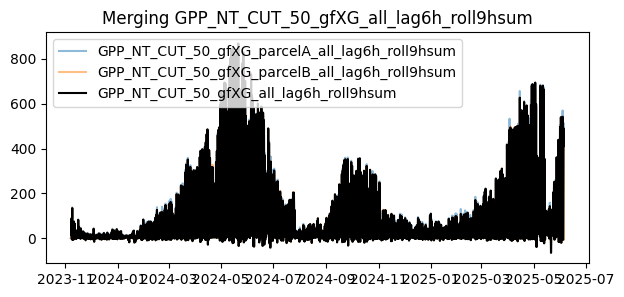

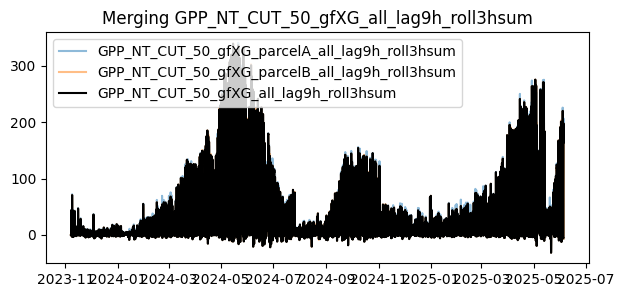

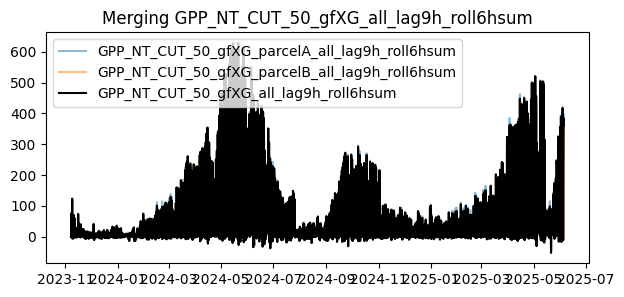

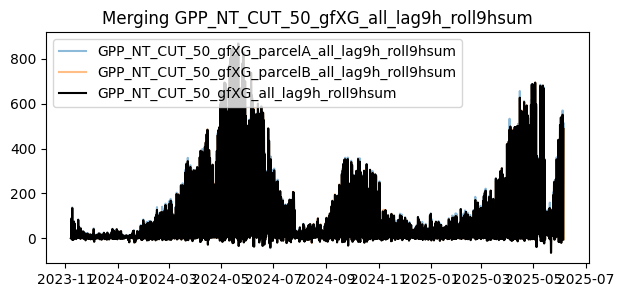

In [16]:
# Merge the split management in one column based on the parcel column
for colA in df.columns:
    if "_parcelA" in colA:
        base = colA.replace("_parcelA", "")
        colB = colA.replace("_parcelA", "_parcelB")
        if colB in df:
            avg_parcels = df[[colA, colB]].mean(axis=1)
            df[base] = np.select(
                [
                    df["parcel_certainty"].eq("uncertain"),  # mixed parcel contribution 
                    df["parcel"] == "A",
                    df["parcel"] == "B"
                ],
                [
                    avg_parcels,      # average of A and B when the contribution is mixed
                    df[colA],      # from A
                    df[colB]       # from B
                ],
                default=np.nan   # others → NaN
            )

            # ---- plot comparison before dropping ----
            plt.figure(figsize=(7, 3))
            plt.plot(df.index, df[colA], label=colA, alpha=0.5)
            plt.plot(df.index, df[colB], label=colB, alpha=0.5)
            plt.plot(df.index, df[base], label=base, alpha=1, color="black")
            plt.title(f"Merging {base}")
            plt.legend()

# EXPORT DATA

## CHECK DATAFRAME

In [17]:
df

,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,trt,SW_IN_POT,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,RECO_NT_CUT_50_gfXG_parcelA_all,GPP_NT_CUT_50_gfXG_parcelA_all,RECO_NT_CUT_50_gfXG_parcelB_all,...,RECO_NT_CUT_50_gfXG_all_lag6h_roll3hmean,RECO_NT_CUT_50_gfXG_all_lag6h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag6h_roll9hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll3hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll9hmean,GPP_NT_CUT_50_gfXG_all_lag3h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll9hsum
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 13:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 13:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 14:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.557946,8.557946,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.263685,8.263685,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.384712,8.384712,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Check what columns are contained in the final dataset

In [18]:
print(f'Dataframe contains {len(df.columns)} columns: {sorted(df.columns)}')

Dataframe contains 285 columns: ['FCH4_L3.3_CUT_50_QCF', 'FCH4_L3.3_CUT_50_QCF0', 'FN2O_L3.3_CUT_50_QCF', 'FN2O_L3.3_CUT_50_QCF0', 'GPP_NT_CUT_50_gfXG_all', 'GPP_NT_CUT_50_gfXG_all_lag3h', 'GPP_NT_CUT_50_gfXG_all_lag3h_roll3hsum', 'GPP_NT_CUT_50_gfXG_all_lag3h_roll6hsum', 'GPP_NT_CUT_50_gfXG_all_lag3h_roll9hsum', 'GPP_NT_CUT_50_gfXG_all_lag6h', 'GPP_NT_CUT_50_gfXG_all_lag6h_roll3hsum', 'GPP_NT_CUT_50_gfXG_all_lag6h_roll6hsum', 'GPP_NT_CUT_50_gfXG_all_lag6h_roll9hsum', 'GPP_NT_CUT_50_gfXG_all_lag9h', 'GPP_NT_CUT_50_gfXG_all_lag9h_roll3hsum', 'GPP_NT_CUT_50_gfXG_all_lag9h_roll6hsum', 'GPP_NT_CUT_50_gfXG_all_lag9h_roll9hsum', 'GPP_NT_CUT_50_gfXG_all_roll3hsum', 'GPP_NT_CUT_50_gfXG_all_roll6hsum', 'GPP_NT_CUT_50_gfXG_all_roll9hsum', 'GPP_NT_CUT_50_gfXG_parcelA_all', 'GPP_NT_CUT_50_gfXG_parcelA_all_lag3h', 'GPP_NT_CUT_50_gfXG_parcelA_all_lag3h_roll3hsum', 'GPP_NT_CUT_50_gfXG_parcelA_all_lag3h_roll6hsum', 'GPP_NT_CUT_50_gfXG_parcelA_all_lag3h_roll9hsum', 'GPP_NT_CUT_50_gfXG_parcelA_all_lag6h

Check the timestamp

In [19]:
# Generate the complete timestamp range
start_date = df.index.min()
end_date = df.index.max()
complete_timestamp = pd.date_range(start=start_date, end=end_date, freq='30min')

# Compare the complete range with the dataframe's index
missing_timestamps = complete_timestamp.difference(df.index)
duplicate_timestamps = df.index[df.index.duplicated()]

# Output the duplicate and missing timestamps
if not duplicate_timestamps.empty:
    print("Duplicate Timestamps:")
    print(duplicate_timestamps)
else:
    print("No duplicate timestamps found.")

if not missing_timestamps.empty:
    print("Missing Timestamps:")
    print(missing_timestamps)
else:
    print("No missing timestamps found.")

# Check if the timestamp is complete and has no duplicates
if duplicate_timestamps.empty and missing_timestamps.empty:
    print("The timestamp index is complete and has no duplicates.")
else:
    print("The timestamp index has issues.")

No duplicate timestamps found.
No missing timestamps found.
The timestamp index is complete and has no duplicates.


## EXPORT

In [20]:
filename = "82.1.1_GapFillingDataset"
save_parquet(data=df, filename=filename)

Saved file 82.1.1_GapFillingDataset.parquet (3.125 seconds).


'82.1.1_GapFillingDataset.parquet'

# **End of notebook**

In [21]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-11-04 15:17:26
